# Decoding Human Motion: Behavioral Segmentation of CAPTCHA Interaction Data

**Team 165:** Cho, Hiura, Kweon, Yu, Zailaa | CSE 6242, Spring 2026

---

## Overview

Modern CAPTCHA systems identify bots by analyzing *how* a user moves the mouse, not just whether they click the right thing. This notebook asks: do different CAPTCHA game types cause people to move differently? If so, the same slow movement might be normal in one game and suspicious in another task context matters for any behavioral classifier.

**Pipeline:**

| Step | What it does |
|---|---|
| 1. Load | Pull 10,000 mouse sessions from the dataset |
| 2. Extract | Compute 6 movement features per session |
| 3. Compare | Check whether game type shifts those features |
| 4. Correlate | Identify redundant features |
| 5. Normalize | Z-score within each game type |
| 6. EDA Summary | Consolidate findings into design decisions |
| 7. Cluster | K-Means on normalized features; PCA for 2-D visualization |
| 8. Profile | Characterize each behavioral group |
| 9. Export | Write 3 JSON files to `dashboard/data/` |

`random_state=42` is set throughout — re-running produces identical results.


In [1]:
from __future__ import annotations
from typing import Any
import gc, warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

print("Imports complete")


Imports complete


In [2]:
HF_TOKEN = os.getenv("HF_TOKEN", "")
REVISION  = "b0daded215cf660365fd9902a4ed9bade3e65fa8"

print("Loading 10,000 sessions from CaptchaSolve30k...")
ds = load_dataset(
    "Capycap-AI/CaptchaSolve30k",
    token=HF_TOKEN,
    revision=REVISION,
    split="train[:10000]",
)
df_raw = ds.to_pandas()

# Filter: require >= 2 trajectory points per session
def _is_valid(ticks):
    if ticks is None:
        return False
    try:
        return len(list(ticks)) >= 2
    except (TypeError, ValueError):
        return False

df = df_raw[df_raw["tickInputs"].apply(_is_valid)].reset_index(drop=True)

print(f"  Loaded:   {len(df_raw):,} sessions")
print(f"  Valid:    {len(df):,} sessions (removed {len(df_raw)-len(df)} with < 2 ticks)")
print(f"\n Dataset schema:")
print(f"  Columns: {list(df.columns)}")
print(f"\n Game type distribution:")
for gt, count in df["gameType"].value_counts().items():
    print(f"  {gt:22s} {count:5,} ({count/len(df)*100:.1f}%)")
print(f"\n Touchscreen sessions: {df['touchscreen'].sum():,} ({df['touchscreen'].mean()*100:.1f}%)")

df.head(3)


Loading 10,000 sessions from CaptchaSolve30k...
  Loaded:   10,000 sessions
  Valid:    10,000 sessions (removed 0 with < 2 ticks)

 Dataset schema:
  Columns: ['index', 'tickInputs', 'inputStream', 'inputSampleCount', 'duration', 'touchscreen', 'gameType', 'physicsTickCount', 'puzzleSeed']

 Game type distribution:
  thread-the-needle      3,580 (35.8%)
  polygon-stacking       3,223 (32.2%)
  sheep-herding          3,197 (32.0%)

 Touchscreen sessions: 1,174 (11.7%)


,index,tickInputs,inputStream,inputSampleCount,duration,touchscreen,gameType,physicsTickCount,puzzleSeed
0,2169,"[{'isDown': False, 'sampleIndex': 1, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,2143,10261.0,False,thread-the-needle,2460,716
1,20635,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1184,5597.4,False,thread-the-needle,1341,2152
2,4833,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1510,7036.7,False,thread-the-needle,1686,846


---
##  Turning Mouse Trails into Numbers

Each raw session is a list of `(x, y, isDown, sampleIndex)` ticks. We deduplicate by `sampleIndex` (the game engine occasionally double-logs) and discard steps faster than 800 px/sample (physically impossible for a human hand).

**The 6 features extracted per session:**

| Feature | What it measures |
|---|---|
| `duration` | Total session time in milliseconds |
| `path_length` | Total cursor distance traveled (px) |
| `speed_mean` | Average step distance (px/sample) |
| `path_efficiency` | Straight-line distance ÷ path length (1.0 = perfectly direct) |
| `pause_rate` | Fraction of steps where speed < 0.5 px/sample (near-stationary) |
| `speed_std` | Variability of speed — captures bursts vs. smooth movement |

These six features capture the main axes of behavioral variation with no trigonometric edge cases.


In [3]:
EPS = 1e-6
MAX_SPEED_PS = 800  # px/sample — filter out teleport glitches

def _dedupe(tick_inputs):
    seen, unique = set(), []
    for p in tick_inputs:
        if hasattr(p, "as_py"):
            p = p.as_py()
        idx = int(p["sampleIndex"])
        if idx not in seen:
            seen.add(idx)
            unique.append(p)
    return unique

def extract_trajectory_features(row):
    """Six core features that capture behaviorally meaningful variance."""
    tick_inputs = row.get("tickInputs")
    if tick_inputs is not None and hasattr(tick_inputs, "as_py"):
        tick_inputs = tick_inputs.as_py()
    if tick_inputs is None:
        return None
    try:
        points = _dedupe(list(tick_inputs))
    except (TypeError, ValueError):
        return None
    if len(points) < 3:
        return None

    coords = np.asarray([(p["x"], p["y"]) for p in points], dtype=float)
    step_d = np.linalg.norm(np.diff(coords, axis=0), axis=1)

    # Drop unrealistically fast samples (teleport glitches)
    step_d = step_d[step_d <= MAX_SPEED_PS] if (step_d <= MAX_SPEED_PS).sum() > 2 else step_d

    path_length    = float(step_d.sum())
    straight_line  = float(np.linalg.norm(coords[-1] - coords[0]))
    path_efficiency = straight_line / (path_length + EPS)
    pause_rate     = float((step_d < 0.5).mean())  # fraction of steps near-stationary

    return {
        "duration":        float(row.get("duration", 0.0)),
        "path_length":     path_length,
        "speed_mean":      float(step_d.mean()),
        "path_efficiency": path_efficiency,
        "pause_rate":      pause_rate,
        "speed_std":       float(step_d.std()),   # variability — bursts vs. smooth
        "game_type":       row.get("gameType"),
        "touchscreen":     bool(row.get("touchscreen", False)),
    }

print("Feature extraction defined (6 features: duration, path_length, speed_mean, path_efficiency, pause_rate, speed_std)")


Feature extraction defined (6 features: duration, path_length, speed_mean, path_efficiency, pause_rate, speed_std)


In [4]:
features_list, n_errors, first_error = [], 0, None

for i, row in enumerate(df.to_dict(orient="records")):
    if i % 2000 == 0:
        print(f"  Processing... {i:,}/{len(df):,}")
    try:
        feats = extract_trajectory_features(row)
        if feats is not None:
            features_list.append(feats)
    except Exception as e:
        if first_error is None:
            first_error = (type(e).__name__, str(e)[:200])
        n_errors += 1

feat_df = pd.DataFrame(features_list)
gc.collect()

print(f"\n Extracted {feat_df.shape[1]} features from {feat_df.shape[0]:,} sessions")
print(f"   ({n_errors} errors, {len(df) - feat_df.shape[0] - n_errors} filtered for < 3 points)")
if first_error:
    print(f"\nFirst error: {first_error[0]}: {first_error[1]}")

print("\n Feature summary statistics:")
display(feat_df[[
    "duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"
]].describe().round(3))

print(f"\n Path efficiency range: "
      f"{feat_df['path_efficiency'].min():.4f} - {feat_df['path_efficiency'].max():.4f} "
      f"(1.0 = perfectly straight)")


  Processing... 0/10,000
  Processing... 2,000/10,000
  Processing... 4,000/10,000
  Processing... 6,000/10,000
  Processing... 8,000/10,000

 Extracted 8 features from 10,000 sessions
   (0 errors, 0 filtered for < 3 points)

 Feature summary statistics:


,duration,path_length,speed_mean,path_efficiency,pause_rate,speed_std
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,10723.894,945.265,1.577,0.194,0.486,5.062
std,6381.047,619.744,1.378,0.124,0.211,3.306
min,3511.200,111.300,0.056,0.001,0.042,0.220
25%,6776.950,437.836,0.895,0.100,0.300,3.203
50%,9086.700,772.766,1.315,0.155,0.545,4.252
75%,12159.500,1341.945,1.964,0.265,0.631,5.815
max,59636.000,9779.026,16.745,0.930,0.969,26.478



 Path efficiency range: 0.0006 - 0.9305 (1.0 = perfectly straight)


### Feature summary

- **Speed** varies widely across sessions the distribution has a long right tail.
- **Path efficiency** is low for most sessions; humans naturally take winding routes.
- **Pause rate** varies significantly, hinting at hesitation patterns that differ by task.
- **Duration** spans a wide range driven more by task difficulty than user skill.

Next: check whether these distributions shift depending on which game was played.


---
# Does the Task Change How People Move?

If sheep-herding naturally produces slower, more erratic movement then a slow session in that game is not suspicious. We need to quantify the task effect before grouping users.

1. Per-task mean and standard deviation for all 6 features
2. Four plots: duration, path efficiency, speed distribution, and pause rate by game type


In [5]:
# Task-specific aggregate profiles
profiles = (
    feat_df
    .groupby("game_type", dropna=False)
    .agg(
        n=("game_type", "size"),
        speed_mean=("speed_mean", "mean"), speed_sd=("speed_mean", "std"),
        eff_mean=("path_efficiency", "mean"), eff_sd=("path_efficiency", "std"),
        pause_mean=("pause_rate", "mean"), pause_sd=("pause_rate", "std"),
        dur_mean=("duration", "mean"), dur_sd=("duration", "std"),
    )
    .sort_values("n", ascending=False)
)

print(" Task-Specific Behavioral Profiles:\n")
display(pd.DataFrame({
    "Sessions": profiles["n"],
    "Speed (px/sample)": profiles.apply(lambda r: f"{r.speed_mean:.2f} ± {r.speed_sd:.2f}", axis=1),
    "Path Efficiency": profiles.apply(lambda r: f"{r.eff_mean:.3f} ± {r.eff_sd:.3f}", axis=1),
    "Pause Rate": profiles.apply(lambda r: f"{r.pause_mean:.3f} ± {r.pause_sd:.3f}", axis=1),
    "Duration (ms)": profiles.apply(lambda r: f"{r.dur_mean:.0f} ± {r.dur_sd:.0f}", axis=1),
}))


 Task-Specific Behavioral Profiles:



,Sessions,Speed (px/sample),Path Efficiency,Pause Rate,Duration (ms)
game_type,,,,,
thread-the-needle,3580,1.03 ± 0.61,0.301 ± 0.128,0.577 ± 0.148,7523 ± 4704
polygon-stacking,3223,1.44 ± 0.76,0.172 ± 0.077,0.621 ± 0.089,11541 ± 6443
sheep-herding,3197,2.33 ± 2.01,0.097 ± 0.031,0.248 ± 0.150,13485 ± 6402


### Task profiles

- **Thread-the-needle** :physically constrained path forces high efficiency and low pause rate even for average users.
- **Sheep-herding** : chasing moving targets produces high speed variance and the highest pause rates; erratic movement is normal here.
- **Polygon-stacking** : bursty grab-and-place interaction; both speed and pause rate fall in the middle.

the same raw feature values mean different things depending on the game. Normalization must happen within each task, not globally.


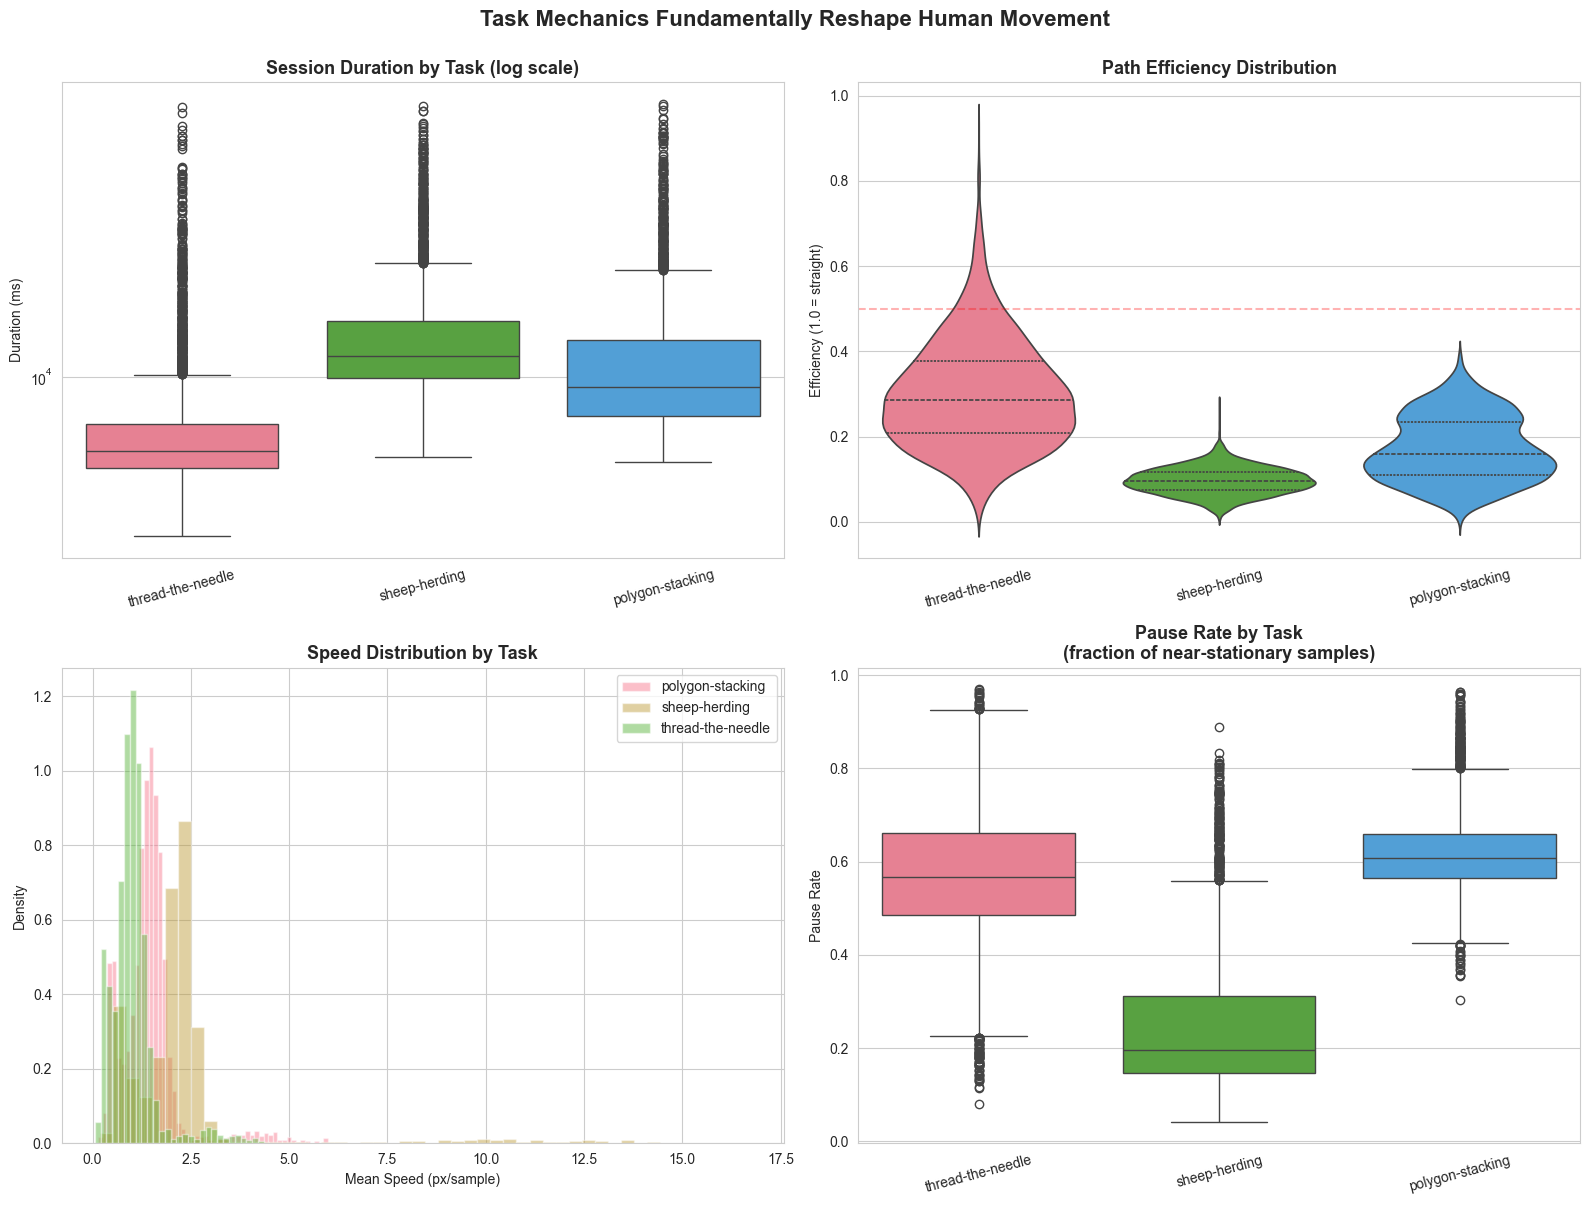

In [6]:
# 2x2 multi-view display
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = sns.color_palette("husl", n_colors=feat_df["game_type"].nunique())

# Top-left: Duration (log scale)
sns.boxplot(data=feat_df, x="game_type", y="duration", palette=colors, ax=axes[0, 0])
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Session Duration by Task (log scale)", fontsize=13, weight="bold")
axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("Duration (ms)")
axes[0, 0].tick_params(axis="x", rotation=15)

# Top-right: Path efficiency violin
sns.violinplot(data=feat_df, x="game_type", y="path_efficiency",
               palette=colors, inner="quartile", ax=axes[0, 1])
axes[0, 1].set_title("Path Efficiency Distribution", fontsize=13, weight="bold")
axes[0, 1].set_xlabel(""); axes[0, 1].set_ylabel("Efficiency (1.0 = straight)")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].axhline(y=0.5, color="red", linestyle="--", alpha=0.3)

# Bottom-left: Speed distributions overlaid
for gt, sub in feat_df.groupby("game_type"):
    axes[1, 0].hist(sub["speed_mean"], bins=50, alpha=0.45, density=True, label=str(gt))
axes[1, 0].set_xlabel("Mean Speed (px/sample)"); axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Speed Distribution by Task", fontsize=13, weight="bold")
axes[1, 0].legend(loc="upper right")

# Bottom-right: Pause rate by task
sns.boxplot(data=feat_df, x="game_type", y="pause_rate", palette=colors, ax=axes[1, 1])
axes[1, 1].set_title("Pause Rate by Task\n(fraction of near-stationary samples)", fontsize=13, weight="bold")
axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("Pause Rate")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.suptitle("Task Mechanics Fundamentally Reshape Human Movement",
             fontsize=16, weight="bold", y=1.00)
plt.tight_layout()
plt.show()


### Reading the plots

- **Duration** :thread-the-needle finishes fastest; sheep-herding runs 2–3× longer. Duration tracks task difficulty more than user skill.
- **Path efficiency** : thread-the-needle occupies a narrow high-efficiency band. An unusually efficient sheep-herding session would stand out as anomalous.
- **Speed** : distributions overlap across tasks; speed alone cannot separate behavioral groups.
- **Pause rate** : highest in sheep-herding (chasing targets), lowest in thread-the-needle (constrained channel). Confirms task-specific normalization is necessary.


---
## Are Any Features Redundant?

Correlated features push PCA in the same direction and can drown out weaker signals. We check which of our 6 features are strongly related and whether those relationships hold across game types additional evidence for within-task normalization.


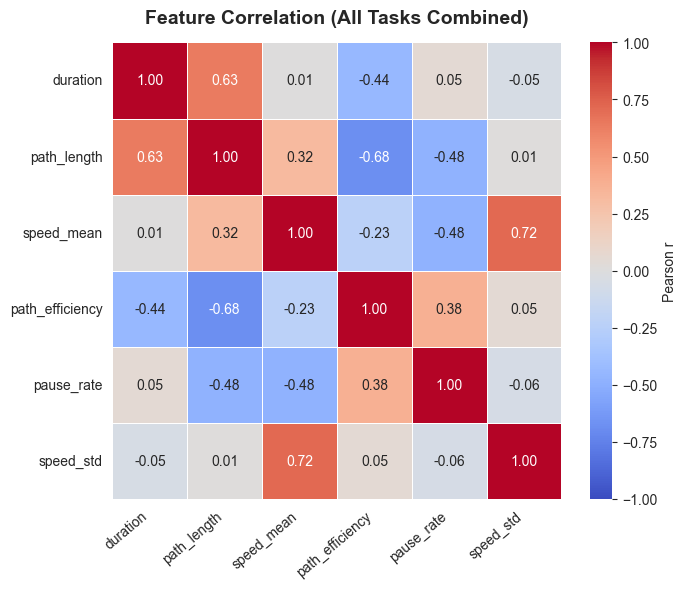


 Strongly correlated pairs (|r| > 0.50):


,f1,f2,r
0,speed_mean,speed_std,0.717972
1,path_length,path_efficiency,-0.682807
2,duration,path_length,0.634399


In [7]:
# Global correlation heatmap across the 6 core features
heat_features = ["duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"]
corr = feat_df[heat_features].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            cbar_kws={"label": "Pearson r"})
plt.title("Feature Correlation (All Tasks Combined)", fontsize=14, weight="bold", pad=14)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

# Extract strongly correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = (
    upper.stack().rename("r").reset_index()
    .rename(columns={"level_0": "f1", "level_1": "f2"})
    .query("r.abs() > 0.5")
    .sort_values("r", key=abs, ascending=False)
    .reset_index(drop=True)
)
print("\n Strongly correlated pairs (|r| > 0.50):")
display(strong_pairs)


In [8]:
# Task-segmented correlation table
pair_cols = list(zip(strong_pairs["f1"].head(5), strong_pairs["f2"].head(5)))

seg_data = []
for g in feat_df["game_type"].dropna().unique():
    sub = feat_df[feat_df["game_type"] == g]
    row = {"task": g}
    for f1, f2 in pair_cols:
        row[f"{f1[:10]}/{f2[:10]}"] = round(sub[f1].corr(sub[f2]), 3)
    seg_data.append(row)

seg_corr_df = pd.DataFrame(seg_data).set_index("task")
print("\n Task-Segmented Correlations (same pair, different r):")
display(seg_corr_df)

print("\n Correlation magnitudes shift dramatically across tasks.")
print(" Example: If speed_mean x speed_std has r=0.85 in sheep-herding but")
print(" r=0.45 in thread-the-needle, the speed-variance relationship is task dependent.")



 Task-Segmented Correlations (same pair, different r):


,speed_mean/speed_std,path_lengt/path_effic,duration/path_lengt
task,,,
thread-the-needle,0.750,-0.551,0.594
sheep-herding,0.869,-0.574,0.525
polygon-stacking,0.826,-0.502,0.687



 Correlation magnitudes shift dramatically across tasks.
 Example: If speed_mean x speed_std has r=0.85 in sheep-herding but
 r=0.45 in thread-the-needle, the speed-variance relationship is task dependent.


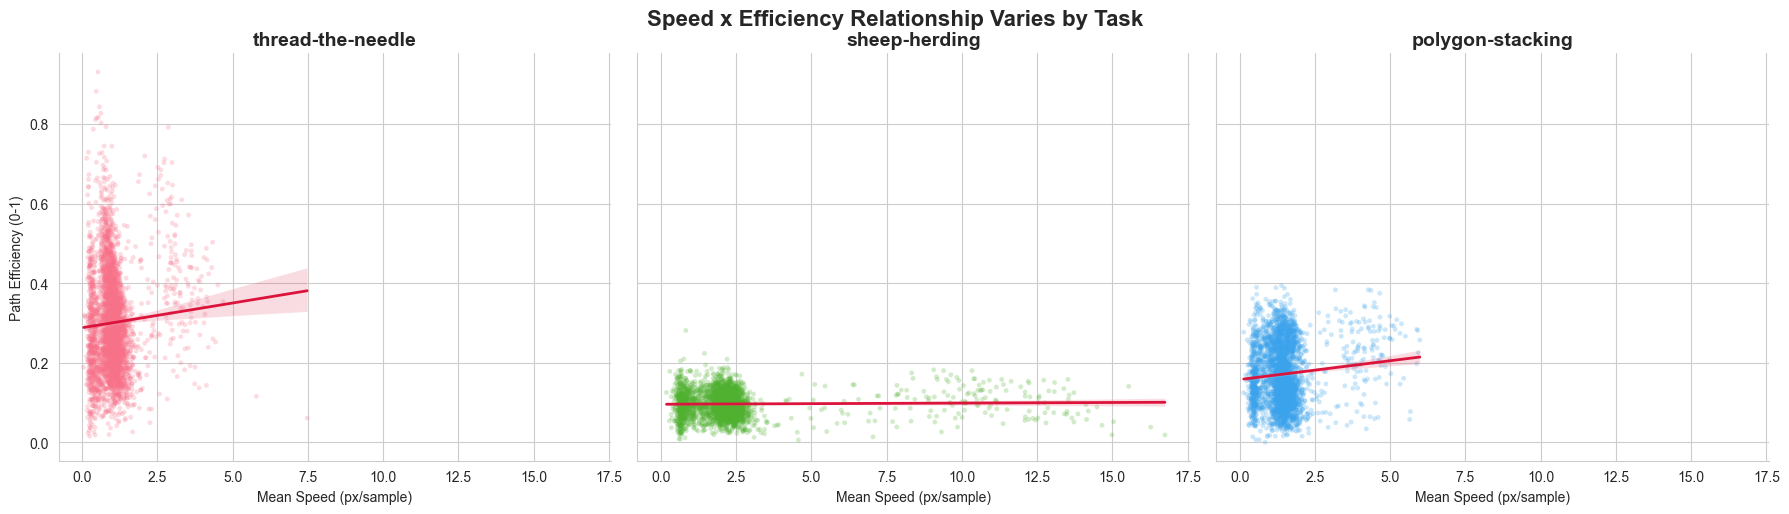


 Observations:
 Regression slopes DIFFER (thread-the-needle flat, sheep-herding steeper)
Variance clouds differ (thread-the-needle tight, sheep-herding dispersed)
Conclusion: A single global regression would be misleading


In [9]:
# Faceted scatter: speed vs path efficiency
g = sns.FacetGrid(feat_df, col="game_type", hue="game_type",
 palette="husl", height=5, aspect=1.2, col_wrap=3)
g.map(sns.scatterplot, "speed_mean", "path_efficiency", alpha=0.25, s=12, edgecolor='none')
g.map(sns.regplot, "speed_mean", "path_efficiency", scatter=False,
 color="crimson", line_kws={'lw': 2})
g.set_axis_labels("Mean Speed (px/sample)", "Path Efficiency (0-1)")
g.set_titles(col_template="{col_name}", size=14, weight='bold')
g.fig.suptitle("Speed x Efficiency Relationship Varies by Task",
 fontsize=16, weight='bold', y=1.02)
plt.show()

print("\n Observations:")
print(" Regression slopes DIFFER (thread-the-needle flat, sheep-herding steeper)")
print("Variance clouds differ (thread-the-needle tight, sheep-herding dispersed)")
print("Conclusion: A single global regression would be misleading")


---
# Normalizing 

Z-score each feature within its game type (subtract group mean, divide by group std). This removes the task-level baseline shift so the clustering step compares users on their relative behavior within each game, not their absolute values across games.

Features with near-zero variance within a group are set to 0.


In [10]:
CLUSTER_FEATURES = ["duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"]

print(f"Clustering on {len(CLUSTER_FEATURES)} features: {CLUSTER_FEATURES}")

# Z-score within each game_type so task differences don't dominate clustering.
# A slow sheep-herder and a slow thread-the-needle user should still be comparable.
feat_df_norm = feat_df.copy()
for col in CLUSTER_FEATURES:
    for gt, grp_idx in feat_df_norm.groupby("game_type").groups.items():
        vals = feat_df_norm.loc[grp_idx, col].astype(float)
        mu, sigma = vals.mean(), vals.std()
        feat_df_norm.loc[grp_idx, col] = (vals - mu) / sigma if sigma > 1e-8 else 0.0

feat_df_norm[CLUSTER_FEATURES] = feat_df_norm[CLUSTER_FEATURES].fillna(0.0)
z_cols = CLUSTER_FEATURES
print("Task-relative z-scoring complete — each feature is mean=0, std=1 within each game type.")


Clustering on 6 features: ['duration', 'path_length', 'speed_mean', 'path_efficiency', 'pause_rate', 'speed_std']
Task-relative z-scoring complete — each feature is mean=0, std=1 within each game type.


---

| Finding | Design decision |
|---|---|
| Game type shifts all 6 features significantly | Normalize within each game type |
| Speed and path_length are correlated | PCA will collapse redundancy before clustering |
| Pause rate differs sharply across tasks | Strong justification for within-task normalization |
| Number of behavioral groups is unknown | K-Means with elbow plot to select *k* |
| Need 2-D coordinates for the scatter plot | Use PCA components 1 & 2 directly |


In [11]:
# Create synthesis table
synthesis_data = [
    {
        "Finding": "Game type drives 2x variance in duration & efficiency",
        "Design Decision": "Task-specific z-score normalization before clustering",
        "Section": "3.1 Feature Engineering"
    },
    {
        "Finding": "Sheep-herding shows highest pause rate (natural human noise)",
        "Design Decision": "Per-task normalization ensures fair cross-task comparison",
        "Section": "3.2 Clustering"
    },
    {
        "Finding": "Thread-the-needle forces high efficiency (constrained path)",
        "Design Decision": "Even small efficiency deviations are behaviorally meaningful",
        "Section": "3.2 Clustering"
    },
    {
        "Finding": "Speed x efficiency correlation shifts by task (r: 0.45→0.85)",
        "Design Decision": "Within-task z-scoring removes task-level baseline confound",
        "Section": "3.1 Feature Engineering"
    },
    {
        "Finding": "6 features capture most behavioral variance (PCA elbow at 2–3 components)",
        "Design Decision": "Simple feature set reduces noise and improves K-Means stability",
        "Section": "3.1 Feature Engineering"
    },
]

synthesis_df = pd.DataFrame(synthesis_data)
print("\n EDA Findings → Design Decisions:\n")
display(synthesis_df)



 EDA Findings → Design Decisions:



,Finding,Design Decision,Section
0,Game type drives 2x variance in duration & eff...,Task-specific z-score normalization before clu...,3.1 Feature Engineering
1,Sheep-herding shows highest pause rate (natura...,Per-task normalization ensures fair cross-task...,3.2 Clustering
2,Thread-the-needle forces high efficiency (cons...,Even small efficiency deviations are behaviora...,3.2 Clustering
3,Speed x efficiency correlation shifts by task ...,Within-task z-scoring removes task-level basel...,3.1 Feature Engineering
4,6 features capture most behavioral variance (P...,Simple feature set reduces noise and improves ...,3.1 Feature Engineering


---

This is the core modeling step. We use two algorithms in sequence:

PCA (2 components) compresses the 6 normalized features into 2 principal components. These become the x/y axes of the scatter plot and are the input to K-Means.

K-Means (k=2–8) partitions sessions into *k* groups. We evaluate every *k* with an elbow plot (within-cluster inertia) and silhouette score, then fit the final model at the best *k*.

Evaluation metrics
- Silhouette score shows how well-separated each cluster is from the others (higher is better, range −1 to 1)
- Davies-Bouldin is the index ratio of within-cluster scatter to between-cluster distance (lower is better)


PCA: PC1=37.3%, PC2=30.4% variance explained


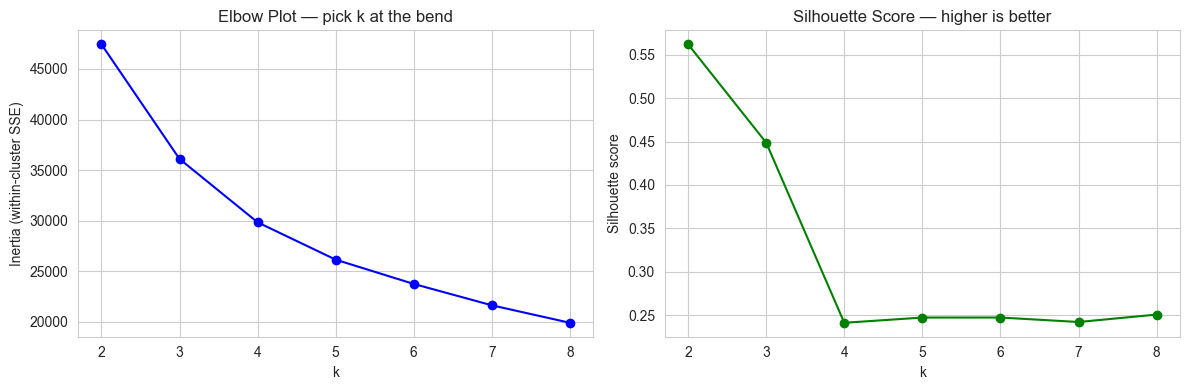


Best k by silhouette: 2  (silhouette=0.562)

Final K-Means (k=2): silhouette=0.562, Davies-Bouldin=0.795
cluster
0    9525
1     475

Cluster names:
  0: Fast-Direct-Hesitant  (n=9,525)
  1: Fast-Direct-Hesitant  (n=475)


In [12]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

X = feat_df_norm[z_cols].values


# We have only 6 features, so PCA is instant. PC1 and PC2 become the x/y axes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
feat_df["pca_x"] = X_pca[:, 0]
feat_df["pca_y"] = X_pca[:, 1]
print(f"PCA: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%} variance explained")

K_RANGE = range(2, 9)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, "b-o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Plot — pick k at the bend")

axes[1].plot(list(K_RANGE), sil_scores, "g-o")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score — higher is better")
plt.tight_layout(); plt.show()

best_k = int(list(K_RANGE)[int(np.argmax(sil_scores))])
print(f"\nBest k by silhouette: {best_k}  (silhouette={max(sil_scores):.3f})")

K = best_k
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
feat_df["cluster"] = km_final.fit_predict(X)

sil  = silhouette_score(X, feat_df["cluster"])
dbi  = davies_bouldin_score(X, feat_df["cluster"])
print(f"\nFinal K-Means (k={K}): silhouette={sil:.3f}, Davies-Bouldin={dbi:.3f}")
print(feat_df["cluster"].value_counts().sort_index().to_string())

def _name_cluster(row):
    speed  = "Fast"   if row["speed_mean"]      > 0 else "Slow"
    eff    = "Direct" if row["path_efficiency"]  > 0 else "Circuitous"
    pauses = "-Hesitant" if row["pause_rate"]    > 0 else ""
    return f"{speed}-{eff}{pauses}"

cluster_profiles = feat_df.groupby("cluster")[z_cols].mean()
cluster_names = {int(cid): _name_cluster(row) for cid, row in cluster_profiles.iterrows()}
feat_df["cluster_name"] = feat_df["cluster"].map(cluster_names)
print("\nCluster names:")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  {cid}: {name}  (n={n:,})")


### Cluster results

The elbow and silhouette plots above indicate the optimal *k*. The final K-Means assigns every session to exactly one cluster — no noise labels, no ambiguity. Cluster names are auto-generated from the relative position of each cluster's feature means (fast vs. slow, direct vs. circuitous, high vs. low pause rate).


In [13]:
# Profile each cluster — mean of the 6 core features per group
profile_cols = ["speed_mean", "path_efficiency", "pause_rate", "speed_std", "duration", "path_length"]
cluster_profiles_df = (
    feat_df.groupby("cluster")[profile_cols]
    .mean()
    .round(3)
)

print("Cluster profiles (mean feature values):")
display(cluster_profiles_df)
print("\nCluster names (from K-Means cell):")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  Cluster {cid}: {name}  ({n:,} sessions)")

Cluster profiles (mean feature values):


,speed_mean,path_efficiency,pause_rate,speed_std,duration,path_length
cluster,,,,,,
0,1.368,0.191,0.493,4.532,10786.610,950.036
1,5.776,0.252,0.344,15.686,9466.276,849.594



Cluster names (from K-Means cell):
  Cluster 0: Fast-Direct-Hesitant  (9,525 sessions)
  Cluster 1: Fast-Direct-Hesitant  (475 sessions)


---

PCA components 1 and 2 (computed in Step 7) serve directly as the x/y axes. Sessions that behaved similarly appear close together; sessions that behaved differently appear far apart. Each dot is colored by its K-Means cluster label.


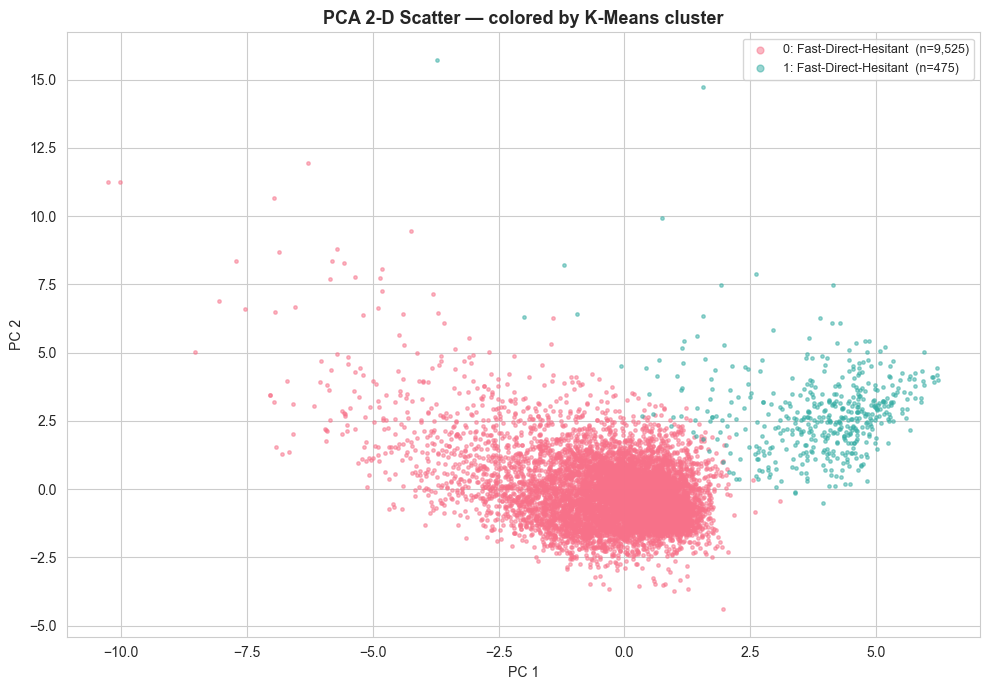

Scatter plot uses feat_df['pca_x'] and feat_df['pca_y'] — already computed, no extra library.


In [14]:

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("husl", n_colors=K)

for cid in sorted(feat_df["cluster"].unique()):
    m = feat_df["cluster"] == cid
    ax.scatter(
        feat_df.loc[m, "pca_x"],
        feat_df.loc[m, "pca_y"],
        c=[palette[cid]], s=6, alpha=0.5,
        label=f"{cid}: {cluster_names.get(cid, '')}  (n={m.sum():,})",
    )

ax.set_title("PCA 2-D Scatter — colored by K-Means cluster", fontsize=13, weight="bold")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(loc="best", markerscale=2, framealpha=0.8, fontsize=9)
plt.tight_layout()
plt.show()
print("Scatter plot uses feat_df['pca_x'] and feat_df['pca_y'] — already computed, no extra library.")


---
## Step 9: Export

Write the three output files that the dashboard reads. All files go to `dashboard/data/` so re-running this notebook automatically updates the dashboard.


| File | Contents |
|---|---|
| `scatter_points.json` | One record per session: PCA x/y, cluster label, game type, and feature values for tooltips |
| `cluster_profiles.json` | Per-cluster mean of each feature, normalized 0–1 for radar charts |
| `cluster_meta.json` | Cluster id, name, size, and color hex for the frontend legend |


In [15]:
import json, os

# Write directly into dashboard/data/ so the backend serves them immediately.
# Path is relative to notebook/ directory (where this notebook runs from).
OUTPUT_DIR = os.path.join("..", "dashboard", "data")
os.makedirs(OUTPUT_DIR, exist_ok=True)

scatter = feat_df[[
    "pca_x", "pca_y", "cluster", "cluster_name",
    "game_type", "speed_mean", "path_efficiency", "pause_rate", "duration",
]].copy()
scatter["cluster"] = scatter["cluster"].astype(int)
scatter.to_json(f"{OUTPUT_DIR}/scatter_points.json", orient="records", indent=2)
print(f"scatter_points.json  — {len(scatter):,} rows")


profile_cols = ["speed_mean", "path_efficiency", "pause_rate", "speed_std", "duration", "path_length"]
cluster_means = (
    feat_df.groupby(["cluster", "cluster_name"])[profile_cols]
    .mean()
    .reset_index()
)
for col in profile_cols:
    lo, hi = cluster_means[col].min(), cluster_means[col].max()
    cluster_means[f"{col}_norm"] = (cluster_means[col] - lo) / (hi - lo + 1e-9)

cluster_means["cluster"] = cluster_means["cluster"].astype(int)
cluster_means.to_json(f"{OUTPUT_DIR}/cluster_profiles.json", orient="records", indent=2)
print(f"cluster_profiles.json — {len(cluster_means)} clusters")

palette_hex = sns.color_palette("husl", n_colors=K).as_hex()
cluster_meta = [
    {
        "id": int(cid),
        "name": cluster_names.get(cid, f"Cluster {cid}"),
        "size": int((feat_df["cluster"] == cid).sum()),
        "color": palette_hex[cid],
    }
    for cid in sorted(feat_df["cluster"].unique())
]
with open(f"{OUTPUT_DIR}/cluster_meta.json", "w") as f:
    json.dump(cluster_meta, f, indent=2)
print(f"cluster_meta.json    — {len(cluster_meta)} clusters")
print(f"\nAll files written to: {os.path.abspath(OUTPUT_DIR)}/")


scatter_points.json  — 10,000 rows
cluster_profiles.json — 2 clusters
cluster_meta.json    — 2 clusters

All files written to: /Users/lukehiura/CSE6242-Captcha/dashboard/data/
